# Анализ результатов favorita

ноутбук собирает metrics.csv из последних запусков results/validation_* и строит короткую таблицу для отчета

In [1]:
from pathlib import Path
import pandas as pd

base_dir = Path.cwd()
if (base_dir / 'results').exists():
    base_dir = base_dir / 'results'
result_dirs = sorted(base_dir.glob('validation_*'))
rows = []
for run_dir in result_dirs:
    metrics_path = run_dir / 'metrics.csv'
    if metrics_path.exists():
        df = pd.read_csv(metrics_path)
        df.insert(0, 'run', run_dir.name)
        rows.append(df)

metrics = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
metrics.sort_values(['nwrmsle', 'run']).head(20)

,run,model,nwrmsle,rmsle,mae,rmse,wmape
15,validation_20260908_183443,catboost,0.763403,0.776977,46.830542,159.133906,0.335821
18,validation_20260908_184151,catboost,0.768274,0.781743,49.710671,160.627753,0.356475
5,validation_20260908_114222,catboost,0.799784,0.814294,49.086592,153.322606,0.351999
10,validation_20260908_115553,catboost,0.799784,0.814294,49.086592,153.322606,0.351999
12,validation_20260908_182840,catboost,0.799784,0.814294,49.086592,153.322606,0.351999
2,validation_20260908_113627,catboost,0.825400,0.848441,68.107004,202.878497,0.342589
21,validation_20260908_184921,catboost,0.833227,0.860119,104.132004,321.725068,0.324531
27,validation_20260908_185540,catboost,0.833227,0.860119,104.132004,321.725068,0.324531
28,validation_20260908_185540,torch_mlp,0.909831,0.936059,117.558738,319.750828,0.366376
6,validation_20260908_114222,seasonal_naive,1.177421,1.200885,79.730206,248.326535,0.571744


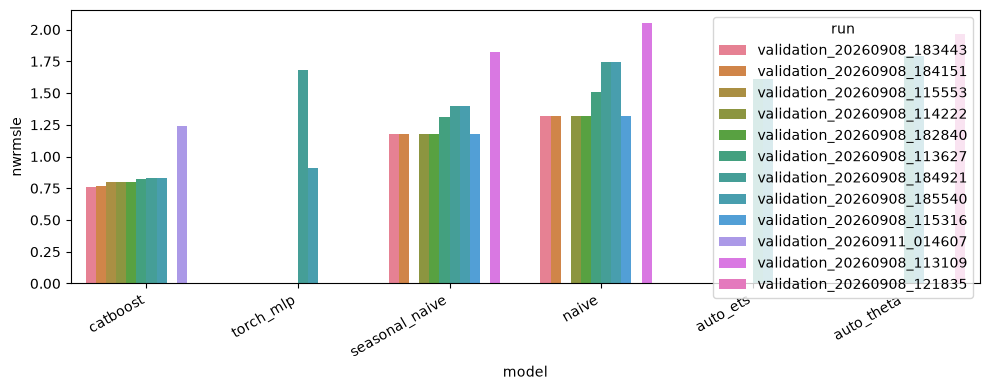

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

if not metrics.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=metrics.sort_values('nwrmsle'), x='model', y='nwrmsle', hue='run')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()